# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [32]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}
stats = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (np.mean(scores), np.std(scores))

    mean_cv_f1 = np.mean(scores)
    std_cv_f1 = np.std(scores)
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred_test, average='macro')

    stats[name] = (mean_cv_f1, std_cv_f1, test_f1)

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

for i in stats:
    print(i, "mean_cv_f1:", stats[i][0], "std_cv_f1:", stats[i][1], "test_f1:", stats[i][2])

#оценка на тестовой выборке


SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139
SVM mean_cv_f1: 0.9693565776676178 std_cv_f1: 0.019323269546947172 test_f1: 0.9811507936507937
RandomForest mean_cv_f1: 0.9504270515323509 std_cv_f1: 0.025455173789956678 test_f1: 0.9526381387619444
LogisticRegression mean_cv_f1: 0.9787292455543591 std_cv_f1: 0.01385774933625734 test_f1: 0.9811507936507937


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [34]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [35]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

DataFrame = pd.DataFrame(svm_grid_search.cv_results_)
results_df = DataFrame[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
print(results_df.sort_values('rank_test_score').head(10))

                                               params  mean_test_score  \
14  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
22  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...         0.976157   
16  {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...         0.971340   
6   {'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...         0.969357   
12  {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...         0.969350   
20  {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...         0.966936   
8   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
5         0.015266                2  
3         0.015266               

In [36]:
#оценка svm на test
y_pred_test = svm_grid_search.predict(X_test)
f1_svm_test = f1_score(y_test, y_pred_test, average='macro')
print(f"F1 на тестовой выборке для SVM: {f1_svm_test:.4f}")

F1 на тестовой выборке для SVM: 0.9812


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': [randint(2, 20), None],
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

#оценка rf на test
y_pred_test_rf = rf_random_search.predict(X_test)
f1_rf_test = f1_score(y_test, y_pred_test_rf, average='macro')
print(f"F1 на тестовой выборке для Random Forest: {f1_rf_test:.4f}")

Лучшие параметры RF: {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 8, 'n_estimators': 477}
Лучший CV F1: 0.9554
F1 на тестовой выборке для Random Forest: 0.9526


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [ ]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# Оценка лучшей модели SVM на тесте
best_svm = svm_grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test)
print("SVM Grid Search Classification Report:")
print(classification_report(y_test, y_pred_svm))
# Оценка лучшей модели RF на тесте
best_rf = rf_random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Random Forest Random Search Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |             0.969 |    0.981 |
# | SVM Grid Search       |             0.979 |    0.98 |
# | RF baseline           |             0.950 |    0.953 |
# | RF Random Search      |             0.955 |    0.96 |


SVM Grid Search Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Random Forest Random Search Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

<Axes: >

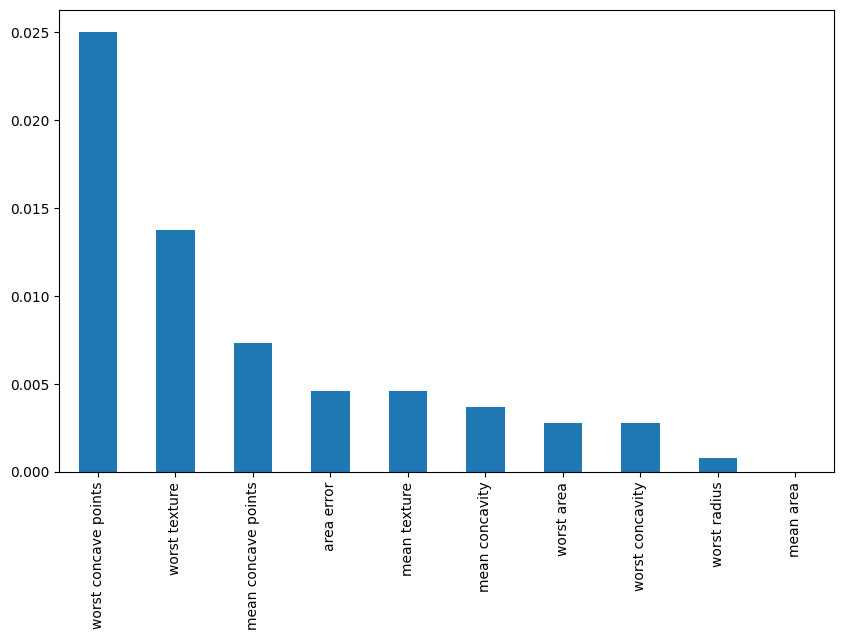

In [39]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
feature_importances = pd.Series(pi_result.importances_mean, index=feature_names)
top_features = feature_importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_features.plot(kind='bar')

<Axes: >

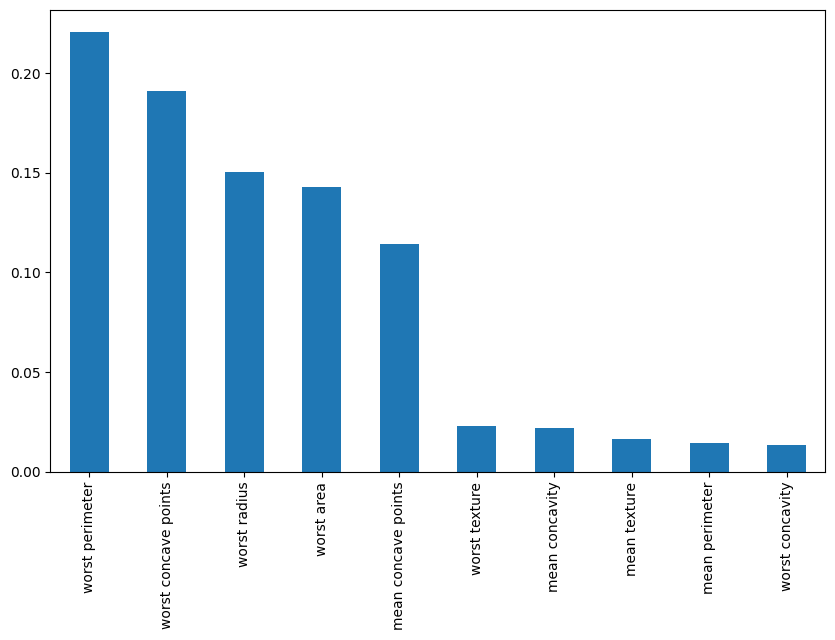

In [ ]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_builtin_importance = pd.Series(best_rf.feature_importances_, index=feature_names)
plt.figure(figsize=(10, 6))
rf_builtin_importance.sort_values(ascending=False).head(10).plot(kind='bar')

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?
#PI отвечает за изменения в работе модели на test при варьировании исходных данных
#Встроенная важность показывает, насколько часто и сильно признак используется в деревьях модели
#например признак worst concave points может быть важным для модели но не часто использоваться в деревьях (например, пограничные случаи), 
#тогда его встроенная важность будет низкой, а PI высокой
#и наоборот, признак (worst perimeter) может часто использоваться в деревьях но не сильно влиять на итоговый результат, 
#тогда его встроенная важность высокая, PI низкий

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

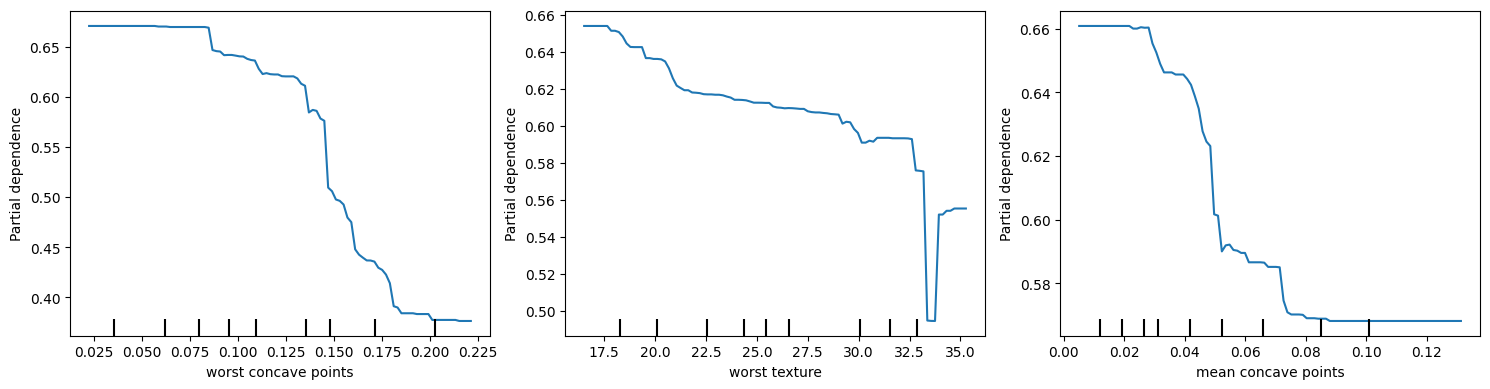

In [41]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = pi_result.importances_mean.argsort()[::-1][:3]
# YOUR CODE HERE

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
for i, idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(best_rf, X_test, [idx], ax=ax[i], kind='average')
plt.tight_layout()
plt.show()

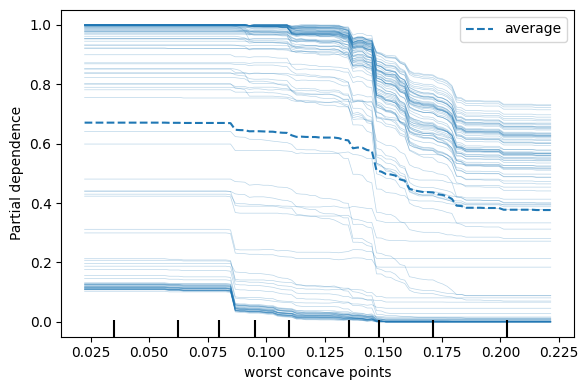

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
most_important_idx = top3_idx[0]
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(best_rf, X_test, [most_important_idx], ax=ax, kind='both')
plt.tight_layout()
plt.show()

#эффект однороден, так как кривые почти не пересекаются
#это значит, что для признака worst concave points влияние на предсказание модели примерно одинаковое для всех объектов
#относительно этого признака ведет себя линейно

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [43]:
# Установка SHAP (если не установлен)
#%pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(shap_values.shape)

(114, 30, 2)


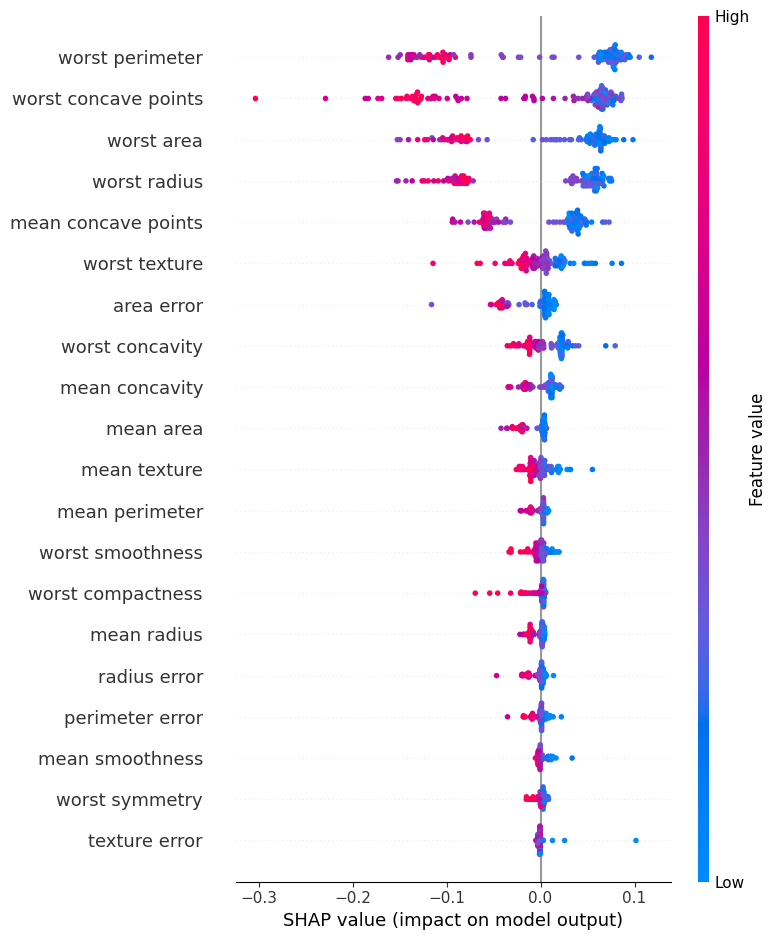

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=feature_names)
plt.show()

#признаки - worst perimeter, worst concave points, worst area, worst radius, mean concave points
#почти совпиадают с PI из шага 6, но есть небольшие различия в порядке важности
#это значит, что модель действительно хорошая, так как разные методы оценки важности признаков дают схожие результаты
#также стоит помнить что breast cancer - немного идеализированный датасет, поэтому в нем четко выделяются самые важные признаки

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


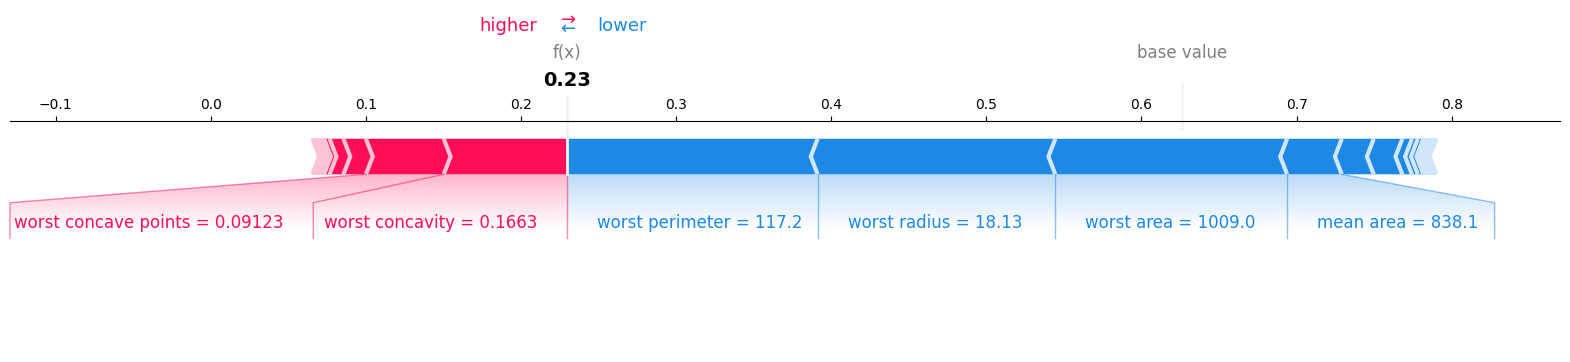

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.force_plot(explainer.expected_value[1], shap_values[errors[0], :, 1], X_test.iloc[errors[0]], feature_names=feature_names, matplotlib=True)

#за ошибку больше всего отвечает worst perimeter, worst radius, worst area
#при этом concave points и concavity error пытаются вытянуть модель, но их влияние не достаточно сильное, чтобы исправить ошибку

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [46]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

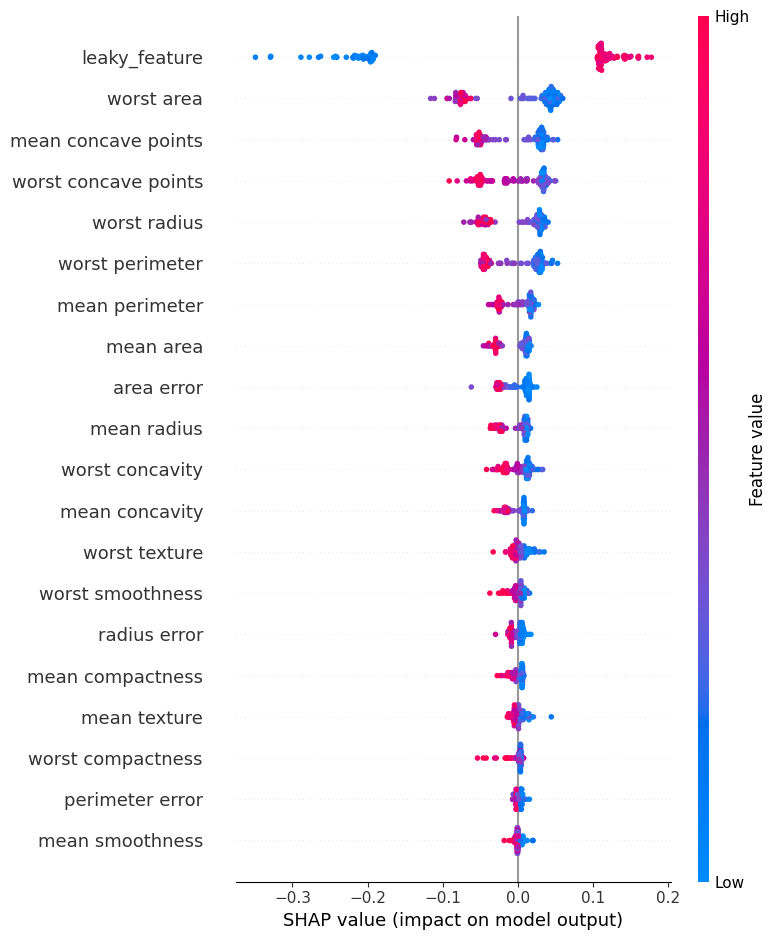

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)
pi_ext = permutation_importance(rf_ext, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro')
explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
shap.summary_plot(shap_values_ext[:, :, 1], X_test_ext, feature_names=X_test_ext.columns)


#посколько laeky_feature почти полностью совпадает с таргетом, PI показывает его как самый важный признак
# метрика на тесте выросла, так как модель теперь может использовать этот костыльный признак для предсказания
#при пострении леса этот признак окажется на верху дерева, но при реальных данных его изменение скорее всего запутает модель полностью

#shap выделяет две зоны - синюю далеко слева и красную далеко справа, что говорит о том
#что при увеличении значения признака модель уверенно предсказывает класс 1, а при уменьшении - класс 0
#так как его значение очень велико из-за почти полной корреляции с таргетом

#чтобы выделить random_feature как шумовой, можно посмотреть на его PI и SHAP значения - они будут близки к нулю, 
#так как этот признак не влияет на предсказания модели
#на графике summary plot он будет находиться внизу списка признаков, а на графике force plot его влияние будет минимальным

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║

# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |             0.969 |    0.981 |
# | SVM Grid Search       |             0.979 |    0.98 |
# | RF baseline           |             0.950 |    0.953 |
# | RF Random Search      |             0.955 |    0.96 |


# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║ 
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
'''модели улучшились, но незначительно, так как изначально они были достаточно хорошими для данного "идеального" датасета.
например базовый svm уже использовал ядро в своем алгоритме, поэтому подбор гиперпараметров не дал радикальных изменений'''
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
'''совпадают, так как оба метода оценивают важность признаков на основе их влияния на предсказания, 
модель опять же обучена на хорошем датасете с четко выделяющимися главными признаками'''
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
'''мы бы получили утечку данных, так как нормализация была бы выполнена на всем датасете, включая тестовую выборку, 
что привело бы к завышенным результатам на тесте и переобучению модели'''
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
'''эти методы можно использовать как для презентации важности признаков заказчику, 
так и для анализа модели при непосредственной работе с данными, например, для выявления проблемных признаков или очистки незначительных для экономии'''
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
print('svm baseline: ', baseline_results['SVM'])
#честно переписал руками, лень перебиррать все переменные:(

svm baseline:  (np.float64(0.9693565776676178), np.float64(0.019323269546947172))


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [49]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")